# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [1]:
# Patch para GPU de Ariel (AMD RX 6750 XT)
%env HSA_OVERRIDE_GFX_VERSION=10.3.0
%env MIOPEN_DEBUG_FIND_ENFORCE=2

env: HSA_OVERRIDE_GFX_VERSION=10.3.0
env: MIOPEN_DEBUG_FIND_ENFORCE=2


In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-15 15:19:21.098781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0-dev0+selfbuilt
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.14.1


In [3]:
import IPython

## Dataset

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [5]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

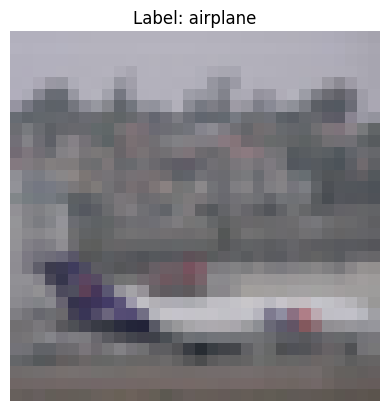

In [6]:
ds_train = ds['train']
ds_test = ds['test']

plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

Se extrae todo el dataset a memoria y se normalizan las imágenes al rango $[0, 1]$:

In [7]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

## Ejercicio 1. Visión por Computadora

In [8]:
def plot_history_graphics(history):
    fig = plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Error de entrenamiento')
    plt.plot(history.history['val_loss'], label='Error de validación')
    plt.title('Curvas de error (categorical cross-entropy)')
    plt.xlabel('Épocas')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy del entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
    plt.title('Curvas de accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Definiendo la red

In [9]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    # Asumiendo estas son Relu como en el tutorial de Tensorflow
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
    layers.Dense(10, activation='softmax', name='output')
])

I0000 00:00:1781536767.790815      39 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11008 MB memory:  -> device: 0, name: AMD Radeon RX 6750 XT, pci bus id: 0000:01:00.0


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
y_train

array([0, 6, 0, ..., 1, 1, 5], shape=(50000,))

Se puede observar que a cada elemento del conjunto de entrenamiento le corresponde en el arreglo `y_train` un número que identifica su clase.
Por lo tanto, se requiere que la función de loss utilizada acepte las clases del dataset de esta forma.
La función `keras.losses.SparseCategoricalCrossentropy()` utilizada en el tutorial de Tensorflow indica en su documentación que espera clases justamente de esta forma, como enteros.

In [12]:
model.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

Se normalizan las imágenes del conjunto de test también al rango $[0,1]$:

In [13]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [14]:
y_test

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [23]:
def train_model_rounds_ex1(model, rounds: int, epochs: int, folder_name: str):
    best_model = (0, 0, None)

    for r in range(rounds):
        # Se mantiene en pantalla solamente la salida de entrenamiento de la última ronda
        # para evitar que el output final sea muy largo.
        IPython.display.clear_output(wait=True)
        
        checkpoint_dir = f'./chk/{folder_name}/round_{r}/'
        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_dir+"{epoch}.keras",
                save_best_only=True,
                monitor="val_accuracy",
                verbose=1,
            )
        ]
    
        # A diferencia del tutorial, se separan parte de los datos para validación,
        # en vez de usar el conjunto de test como tal.
        x_train_split, x_val_split, y_train_split, y_val_split = \
            train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)
    
        # Hay que clonar el modelo original para poder entrenarlo desde cero cada vez.
        model_cur = keras.models.clone_model(model)
        
        history_cur = model_cur.fit(
            x_train_split, y_train_split, epochs=epochs, callbacks=callbacks,
            validation_data=(x_val_split, y_val_split)
        )
    
        checkpoints = [checkpoint_dir + "/" + name for name in os.listdir(checkpoint_dir)]
        latest_checkpoint = max(checkpoints, key=os.path.getctime)
        best_chk = keras.models.load_model(latest_checkpoint)
        test_loss, test_accuracy = best_chk.evaluate(x_test, y_test, verbose=0)
        best_model = max(best_model, (test_accuracy, test_loss, history_cur))

    return best_model

In [16]:
ROUNDS = 5
EPOCHS = 10 # Default del tutorial de Tensorflow
best_model_10ep = train_model_rounds_ex1(model, ROUNDS, EPOCHS, "ex1_10ep")

Epoch 1/10
1398/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2715 - loss: 1.9392
Epoch 1: val_accuracy improved from None to 0.51560, saving model to ./chk/ex1_10ep/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex1_10ep/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3774 - loss: 1.6839 - val_accuracy: 0.5156 - val_loss: 1.3272
Epoch 2/10
1398/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5327 - loss: 1.2888
Epoch 2: val_accuracy improved from 0.51560 to 0.57360, saving model to ./chk/ex1_10ep/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex1_10ep/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5536 - loss: 1.2315 - val_accuracy: 0.5736 - val_loss: 1.2050
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6225 - loss: 1.0649
Epoch 3: val_accuracy improved from 0.57360 to 0.65300, saving model to ./chk/ex1_10ep/round_4/3.keras

Epoch 3: finished saving model to ./chk/ex1_10ep/round_4/3.

Se utilizan checkpoints para guardar el mejor accuracy obtenido entre los obtenidos durante una ronda de entrenamiento. 

Además, se decidió ejecutar varias rondas de entrenamiento para obtener el mejor accuracy entre todas, debido a que se observaron variaciones de alrededor de $1-2\%$ que pueden afectar a la medición de las mejoras de la arquitectura de la CNN propuestas más adelante.

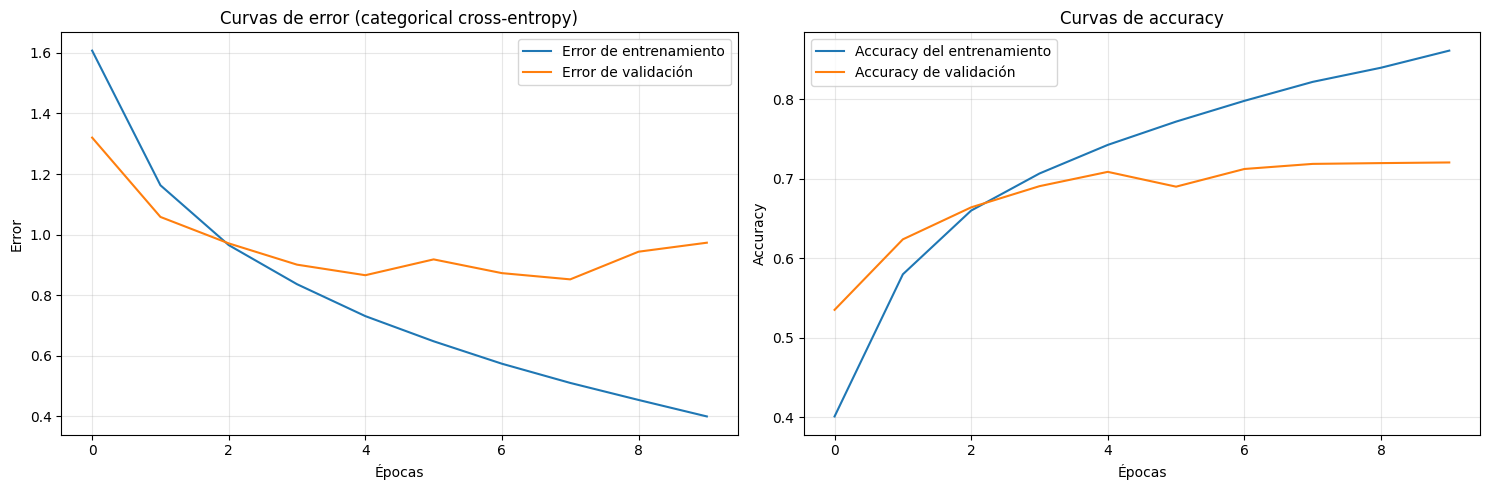

In [17]:
plot_history_graphics(best_model_10ep[2])

In [18]:
print(f'Categorical cross-entropy: {best_model_10ep[1]}')
print(f'Accuracy: {best_model_10ep[0]:.4f} ({best_model_10ep[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_10ep[0]:.4f} ({(1-best_model_10ep[0])*100:.2f}%)')

Categorical cross-entropy: 0.9903419017791748
Accuracy: 0.7187 (71.87%)
Error Rate: 0.2813 (28.13%)


TODO: Observaciones // redacción // formato Latex para números // revisar valores, etc-> El error de entrenamiento baja, y el accuracy de entrenamiento sube. Lo mismo sucede al principio con el conjunto de validación, pero luego se estanca su crecimiento del accuracy, e incluso su error sube algo más en las últimas épocas. La accuracy sobre el conjunto de test es de 73%, y el error de 0.96, probablemente se pueden mejorar (disminuir el error, y aumentar el accuracy).

A pesar de esto, parece que el accuracy se encuentra en aumento con una pendiente considerable, y lo mismo para el descenso del error de entrenamiento.
Es posible entonces que el error de entrenamiento mejore con mayor cantidad de épocas. Elegimos arbitrariamente el doble, 20 épocas.

In [24]:
ROUNDS = 5
EPOCHS = 20
best_model_20ep = train_model_rounds_ex1(model, ROUNDS, EPOCHS, "ex1_20ep")

Epoch 1/20
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3027 - loss: 1.8588
Epoch 1: val_accuracy improved from None to 0.48920, saving model to ./chk/ex1_20ep/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex1_20ep/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3991 - loss: 1.6211 - val_accuracy: 0.4892 - val_loss: 1.4479
Epoch 2/20
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5558 - loss: 1.2315
Epoch 2: val_accuracy improved from 0.48920 to 0.61880, saving model to ./chk/ex1_20ep/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex1_20ep/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5764 - loss: 1.1703 - val_accuracy: 0.6188 - val_loss: 1.0887
Epoch 3/20
1402/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6462 - loss: 0.9912
Epoch 3: val_accuracy improved from 0.61880 to 0.68140, saving model to ./chk/ex1_20ep/round_4/3.keras

Epoch 3: finished saving model to ./chk/ex1_20ep/round_4/3.

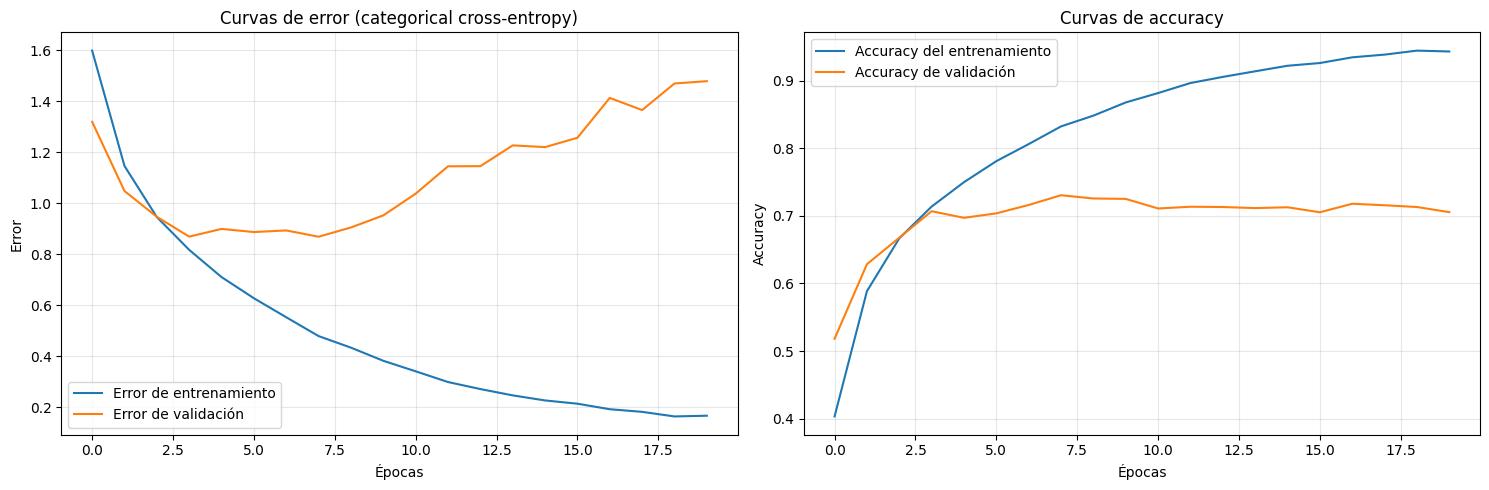

In [25]:
plot_history_graphics(best_model_20ep[2])

In [26]:
print(f'Categorical cross-entropy: {best_model_20ep[1]}')
print(f'Accuracy: {best_model_20ep[0]:.4f} ({best_model_20ep[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_20ep[0]:.4f} ({(1-best_model_20ep[0])*100:.2f}%)')

Categorical cross-entropy: 0.8627658486366272
Accuracy: 0.7261 (72.61%)
Error Rate: 0.2739 (27.39%)


TODO:
Es claro con una mayor cantidad de épocas que el estancamiento del accuracy del conjunto de validación observado con 10 épocas es producto de overfitting, lo cual se evidencia especialmente con 20 épocas. Si bien a mayor cantidad de épocas se logra un menor error en el conjunto de test, el accuracy del conjunto de validación se mantiene en torno al 70%, y su error de categorical cross-entropy de hecho aumenta partiendo de alrededor de la 10° época. TODO: Redacción / números

Además, ambas métricas retornan peores resultados para el conjunto de test respecto a las vistas con 10 épocas: un accuracy de 68% (5% menos) y un loss mayor de 1.42.

Dicho esto, plantearemos una modificación a la arquitectura de la CNN que permita obtener una mejora en el error obtenido:

#### TODO: ENCONTRAR UN CAMBIO QUE AYUDE A MEJORAR LA PERFORMANCE DE LA RED!!!

In [783]:
model_enhanced = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
    layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
    layers.Flatten(name='flatten'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(10, activation='softmax', name='output')
])

In [784]:
model_enhanced.summary()

Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [785]:
model_enhanced.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [786]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

In [787]:
history_enhanced = model_enhanced.fit(
    x_train_split, y_train_split, epochs=10,
    validation_data=(x_val_split, y_val_split)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4103 - loss: 1.5935 - val_accuracy: 0.5414 - val_loss: 1.2896
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6044 - loss: 1.1070 - val_accuracy: 0.6414 - val_loss: 0.9997
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6839 - loss: 0.8941 - val_accuracy: 0.6872 - val_loss: 0.8754
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7345 - loss: 0.7608 - val_accuracy: 0.7124 - val_loss: 0.8461
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7632 - loss: 0.6748 - val_accuracy: 0.7324 - val_loss: 0.7643
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7911 - loss: 0.5961 - val_accuracy: 0.7270 - val_loss: 0.8315
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8116 - loss: 0.5335 - val_accuracy: 0.7466 - val_loss: 0.7559
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8315 - loss: 0

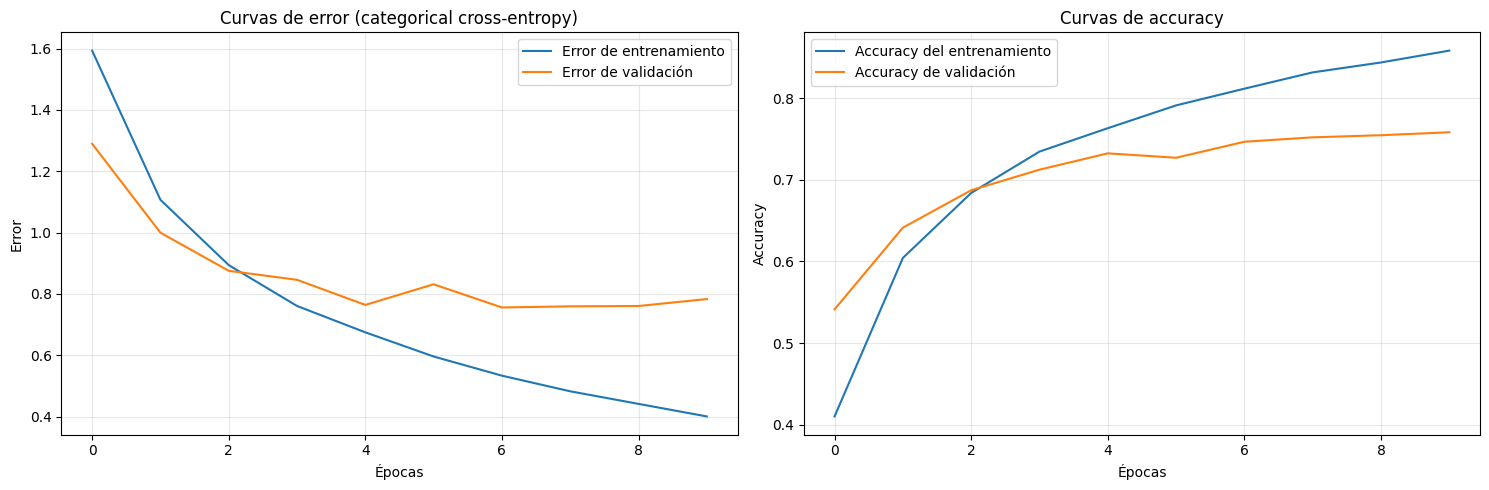

In [788]:
plot_history_graphics(history_enhanced)

In [789]:
model_enhanced.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7563 - loss: 0.7982


[0.7982431650161743, 0.7562999725341797]

## Ejercicio 2. Dropout

In [21]:
def create_model_droput(prob, two_drops): # two_drops es para hacer uno o dos dropouts, capaz se puede hacer mas lindo
    if (not two_drops):
        model_drop = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            # Capa droput
            layers.Dropout(prob, name='dropout_1'),
            layers.Flatten(name='flatten'),
            # Asumiendo estas son Relu como en el tutorial de Tensorflow
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(128, activation='relu', name='dense_3'),
            # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
            layers.Dense(10, activation='softmax', name='output')
        ])
    else:
        model_drop = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            # Capa droput
            layers.Dropout(prob, name='dropout_1'),
            layers.Flatten(name='flatten'),
            # Asumiendo estas son Relu como en el tutorial de Tensorflow
            layers.Dense(64, activation='relu', name='dense_1'),
            # Capa droput
            layers.Dropout(prob, name='dropout_2'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(128, activation='relu', name='dense_3'),
            # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
            layers.Dense(10, activation='softmax', name='output')
        ])

    return model_drop

Entrenamos 5 modelos, 4 en los cuales variamos la cantidad de capas de dropout valores de p pedidos en el enunciado y un modelo extra con 2 capas de dropout y p = 0.7 para experimentar con un valor de p mas alto.
Utilizamos 40 epocas de entrenamiento, el doble de las utilizadas en el ejericio previo.

Entrenamos el modelo model_drop_11 con p = 0.2 y una capa droput

In [22]:
model_drop_11 = create_model_droput(0.2, False)
model_drop_11.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_drop_11.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_11 = model_drop_11.fit(
    x_train, y_train, epochs=40,
    validation_data=(x_test, y_test)
    )

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4168 - loss: 1.5775 - val_accuracy: 0.5617 - val_loss: 1.2120
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5966 - loss: 1.1317 - val_accuracy: 0.5867 - val_loss: 1.1494
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6682 - loss: 0.9436 - val_accuracy: 0.6853 - val_loss: 0.9022
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7121 - loss: 0.8162 - val_accuracy: 0.6956 - val_loss: 0.8680
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7394 - loss: 0.7390 - val_accuracy: 0.7155 - val_loss: 0.8195
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7627 - loss: 0.6766 - val_accuracy: 0.7137 - val_loss: 0.8417
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7861 - loss: 0.6126 - val_accuracy: 0.7217 - val_loss: 0.8375
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8008 - loss: 0.5693

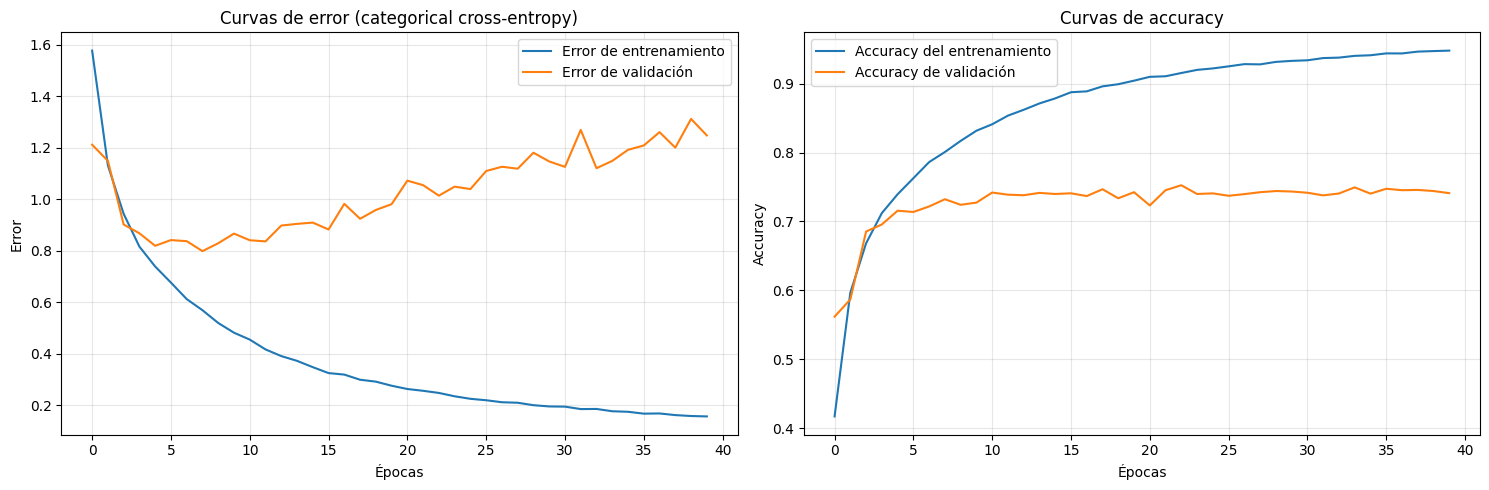

In [24]:
plot_history_graphics(history_drop_11)

Podemos ver que, en principio, agregar una capa de dropout (luego de la ultima capa convolucional) obtenemos un resultado similar en el ejericio 1 (esto sin haber hallado aun la modificación que mejore en almenos 3%) en el cual la curva de error de entrenamiento baja y la de validacion sube. El overfitting observado previamente se mantiene lo cual nos dice que el valor p = 0.2, osea, un 80% de probabilidad de ignorar una neurona de las que conectan la ultima capa convolucional con la capa flatten, no es apropiado para evitar el sobreajuste.

Las curvas de accuracy tento de entrenamiento como de validación, son similares a las del ejericio 1, con un pequeño aumento del accuracy de validación a 75%.

Entrenamos el modelo model_drop_12 con p = 0.2 y dos capas droput

In [25]:
model_drop_12 = create_model_droput(0.2, True)
model_drop_12.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model_drop_12.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_12 = model_drop_12.fit(
    x_train, y_train, epochs=40,
    validation_data=(x_test, y_test)
    )

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3737 - loss: 1.6647 - val_accuracy: 0.5004 - val_loss: 1.3564
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5373 - loss: 1.2764 - val_accuracy: 0.5943 - val_loss: 1.1353
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6115 - loss: 1.0979 - val_accuracy: 0.6414 - val_loss: 1.0225
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6520 - loss: 0.9826 - val_accuracy: 0.6735 - val_loss: 0.9328
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6872 - loss: 0.8909 - val_accuracy: 0.6975 - val_loss: 0.8835
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7116 - loss: 0.8242 - val_accuracy: 0.6965 - val_loss: 0.8774
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7358 - loss: 0.7650 - val_accuracy: 0.7144 - val_loss: 0.8313
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7532 - loss: 0.7120 

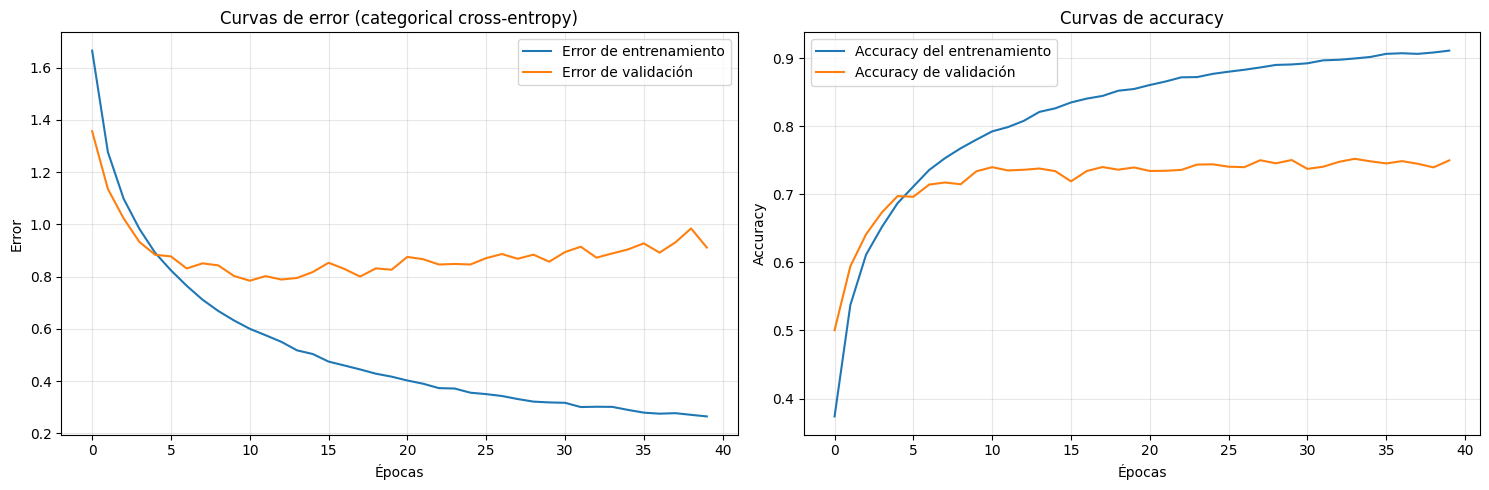

In [27]:
plot_history_graphics(history_drop_12)

En este caso, nuevamente con p = 0.2 pero 2 capas de dropout (una despues de la ultima capa de convolución y otra luego de la primer capa densa), podemos observar que la curva de error de entrenamiento baja tal cual lo vimos anteriormente. Ademas, la curva de error de validación parece tener un comportamiento similar al anterior.
La red sigue overfitteando, por lo que, aumentar la cantidad de capas no ayuda a mejorar el modelo. Este comportamiento similar al usar p = 0.2 y variar la cantidad de capas, nos lleva a pensar que 0.2 NO es un buen valor de p para este problema.

(Probé varias veces y siempre overfittea)

En cuanto a las curvas de accuracy, no hay mucha diferencia con el modelo anterior (con p = 0.2 pero solo una capa de dropout)

Entrenamos el modelo model_drop_21 con p = 0.5 y una capa droput


In [28]:
model_drop_21 = create_model_droput(0.5, False)
model_drop_21.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_drop_21.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_21 = model_drop_21.fit(
    x_train, y_train, epochs=40,
    validation_data=(x_test, y_test)
    )

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3975 - loss: 1.6144 - val_accuracy: 0.5213 - val_loss: 1.2828
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5686 - loss: 1.1927 - val_accuracy: 0.6263 - val_loss: 1.0503
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6367 - loss: 1.0212 - val_accuracy: 0.6744 - val_loss: 0.9251
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6781 - loss: 0.9125 - val_accuracy: 0.7078 - val_loss: 0.8539
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7048 - loss: 0.8382 - val_accuracy: 0.7090 - val_loss: 0.8401
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7235 - loss: 0.7827 - val_accuracy: 0.7157 - val_loss: 0.8173
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7404 - loss: 0.7336 - val_accuracy: 0.7187 - val_loss: 0.8078
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7587 - loss: 0.6908

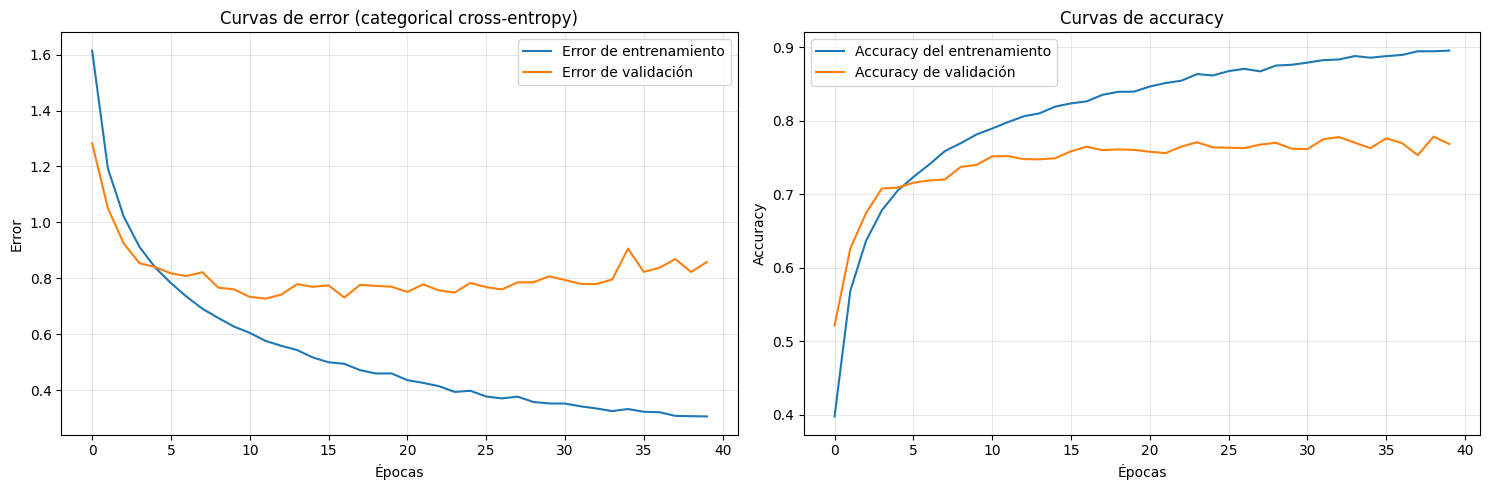

In [30]:
plot_history_graphics(history_drop_21)

Para este modelo, utilizando p = 0.5 y una capa de dropout (luego de la ultima capa convolucional), los resultados obtenidos son similares a los obtenidos en el modelo anterior (con p = 0.2 y dos capas de dropout).

Pareciera ala diferencia que se logro entre las curvas de error de validación usando p = 0.2 con una capa de dropout y usando 2 capas, el valor p = 0.5 lo logra con solo una capa de dropout. Esto nos lleva a pensar que o.5 apunta a ser un valor mas apropiado para este problema.

Entrenamos el modelo model_drop_21 con p = 0.5 y dos capas droput

In [31]:
model_drop_22 = create_model_droput(0.5, True)
model_drop_22.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_drop_22.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_22 = model_drop_22.fit(
    x_train, y_train, epochs=40,
    validation_data=(x_test, y_test)
    )

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3339 - loss: 1.7536 - val_accuracy: 0.4477 - val_loss: 1.4729
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4853 - loss: 1.3987 - val_accuracy: 0.5803 - val_loss: 1.1995
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5534 - loss: 1.2411 - val_accuracy: 0.6186 - val_loss: 1.1172
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5975 - loss: 1.1326 - val_accuracy: 0.6356 - val_loss: 1.0583
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6260 - loss: 1.0570 - val_accuracy: 0.6587 - val_loss: 1.0379
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6475 - loss: 0.9958 - val_accuracy: 0.6534 - val_loss: 1.0540
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6654 - loss: 0.9509 - val_accuracy: 0.6724 - val_loss: 0.9857
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6809 - loss: 0.9090 

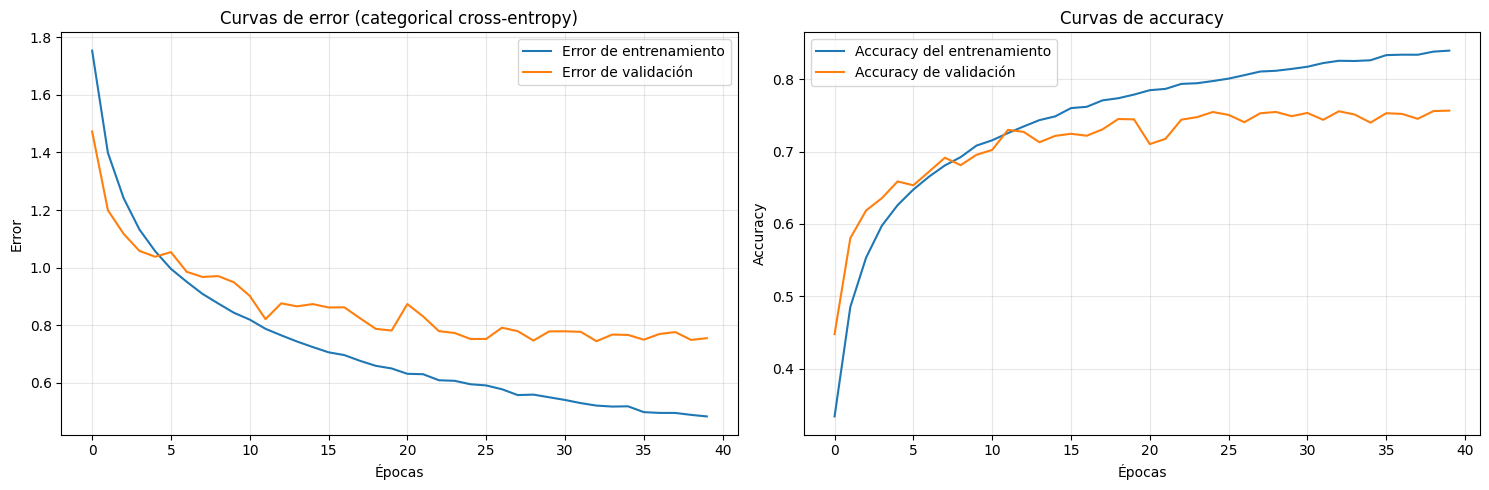

In [33]:
plot_history_graphics(history_drop_22)

Finalmente, usando p = 0.5 y dos capas de dropout (una despues de la ultima capa de convolución y otra luego de la primer capa densa), vemos que, la curva de error de entrenamiento está un poco por encima de los casos anteriores (0.6 aproximadamente), la curva de error de validación parece finalmente dejar de subir para estancarse en 0.8. Este caso es el que menos overfitting sufre de los 4.

##Concusiones generales (Ejercicio 2)
Analizando los graficos, vemos que, para cada valor de p, usar dos capas de dropout mejora el rendimiento de la red respecto de la que usa solo una capa.

Por otro lado, para este problema en particular, valores bajos de p, es decir, probabilidades mas altas de ignorar algunas neuronas, produce peores resultados que valores mas altos de p.

En esencia, el dropout funciona como una técnica de regularización para evitar el sobreajuste, lograr esto depende del valor de p elegido y en que posición se ubican las capas de dropout, y a su vez, esto de depende meramente del problema. En este caso, la mejor ubicación para la capa de dropout parece ser entre capas densas, ya que en estas capas se corre el riesgo de memorizar el conjunto de entrenamiento y asi generar overfit.

A raiz de lo que obtuvimos, ejegimos p = 0.5 y dos capas de dropout como los valores optimos para el ejercicio.

## Ejercicio 3. Data Augmentation

In [41]:
img_height = 32
img_width = 32

data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

model_aug = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            data_augmentation,
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            # Capa droput
            layers.Dropout(0.5, name='dropout_1'),
            layers.Flatten(name='flatten'),
            # Asumiendo estas son Relu como en el tutorial de Tensorflow
            layers.Dense(64, activation='relu', name='dense_1'),
            # Capa droput
            layers.Dropout(0.5, name='dropout_2'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(128, activation='relu', name='dense_3'),
            # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
            layers.Dense(10, activation='softmax', name='output')
])

model_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_aug.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_aug = model_aug.fit(
    x_train, y_train, epochs=40,
    validation_data=(x_test, y_test)
    )

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.2789 - loss: 1.9143 - val_accuracy: 0.3332 - val_loss: 1.7738
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.3980 - loss: 1.6194 - val_accuracy: 0.4763 - val_loss: 1.4327
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4392 - loss: 1.5161 - val_accuracy: 0.5022 - val_loss: 1.4015
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4734 - loss: 1.4458 - val_accuracy: 0.5469 - val_loss: 1.3233
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4925 - loss: 1.3934 - val_accuracy: 0.5186 - val_loss: 1.3475
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5101 - loss: 1.3500 - val_accuracy: 0.5766 - val_loss: 1.1948
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5287 - loss: 1.3053 - val_accuracy: 0.5773 - val_loss: 1.2789
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5382 -

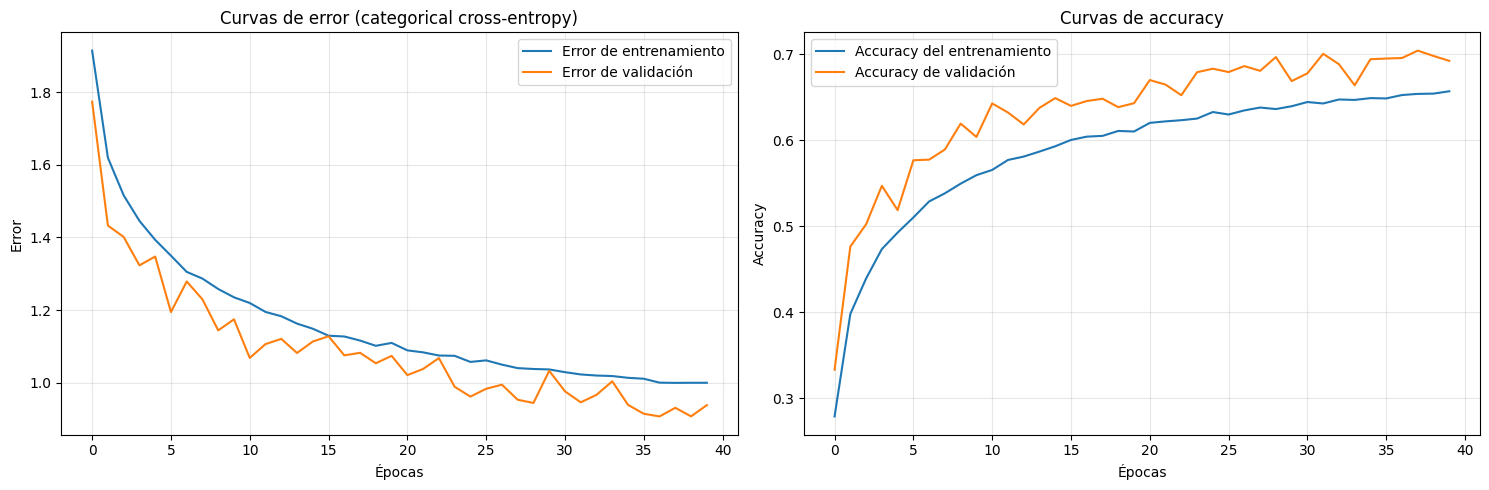

In [43]:
plot_history_graphics(history_aug)

## Ejercicio 4. Transfer Learning

TODO: Hay que hacer con dropout? Probablemente hay que agregar las optimizaciones del 1)!

In [588]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

In [589]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [590]:
# Elegimos arbitrariamente las últimas dos clases para simplificar su eliminación
cond = y_train < 8
x_train8 = x_train[cond]
y_train8 = y_train[cond]

In [591]:
y_train8

array([0, 6, 0, ..., 1, 1, 5], shape=(40000,))

In [592]:
cond = y_test < 8
x_test8 = x_test[cond]
y_test8 = y_test[cond]

In [593]:
y_test8

array([3, 0, 6, ..., 5, 1, 7], shape=(8000,))

In [594]:
model_cifar8 = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    layers.Dense(8, activation='softmax', name='output') # 8 capas de salida
])

In [595]:
model_cifar8.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,248 (1.60 MB)

 Trainable params: 418,248 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

TODO: Loss elegido ok? Métricas?

In [596]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [597]:
x_train8_split, x_val8_split, y_train8_split, y_val8_split = \
    train_test_split(x_train8, y_train8, test_size=0.1, stratify=y_train8)

TODO: Cantidad épocas? Usar Model Checkpoint para agarrar con la mejor validación?

In [598]:
history_cifar8 = model_cifar8.fit(
    x_train8_split, y_train8_split, epochs=10,
    validation_data=(x_val8_split, y_val8_split)
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4166 - loss: 1.5287 - val_accuracy: 0.5393 - val_loss: 1.2303
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5798 - loss: 1.1395 - val_accuracy: 0.6133 - val_loss: 1.0741
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6432 - loss: 0.9814 - val_accuracy: 0.6560 - val_loss: 0.9502
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6928 - loss: 0.8581 - val_accuracy: 0.6720 - val_loss: 0.9124
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7276 - loss: 0.7627 - val_accuracy: 0.6917 - val_loss: 0.8651
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7566 - loss: 0.6846 - val_accuracy: 0.7005 - val_loss: 0.8690
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7852 - loss: 0.6083 - val_accuracy: 0.7153 - val_loss: 0.8567
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8075 - loss: 0.5443 - 

In [599]:
cond = y_train >= 8
x_train2 = x_train[cond] - 8   # Restamos para tener clases 0,1 
y_train2 = y_train[cond] - 8

In [600]:
y_train2

array([0, 0, 1, ..., 0, 1, 1], shape=(10000,))

In [601]:
cond = y_test >= 8
x_test2 = x_test[cond] - 8 
y_test2 = y_test[cond] - 8

In [602]:
y_test2

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [603]:
model_cifar8.pop()
for layer in model_cifar8.layers:
    layer.trainable = False

In [604]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   N   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 417,216 (1.59 MB)

 Optimizer params: 836,498 (3.19 MB)

In [605]:
model_cifar2 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [606]:
model_cifar2.summary()

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 417,216 (1.59 MB)

In [607]:
model_cifar2.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [608]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [609]:
history_cifar2 = model_cifar2.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5082 - loss: 1.6986 - val_accuracy: 0.5690 - val_loss: 0.6861
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6096 - loss: 0.6635 - val_accuracy: 0.6540 - val_loss: 0.6247
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6508 - loss: 0.6318 - val_accuracy: 0.7050 - val_loss: 0.5935
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6659 - loss: 0.6137 - val_accuracy: 0.6580 - val_loss: 0.5999
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6660 - loss: 0.6142 - val_accuracy: 0.6990 - val_loss: 0.5845
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6727 - loss: 0.6117 - val_accuracy: 0.6440 - val_loss: 0.6325
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6746 - loss: 0.6048 - val_accuracy: 0.6630 - val_loss: 0.5950
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6681 - loss: 0.6095 - val_accuracy: 0

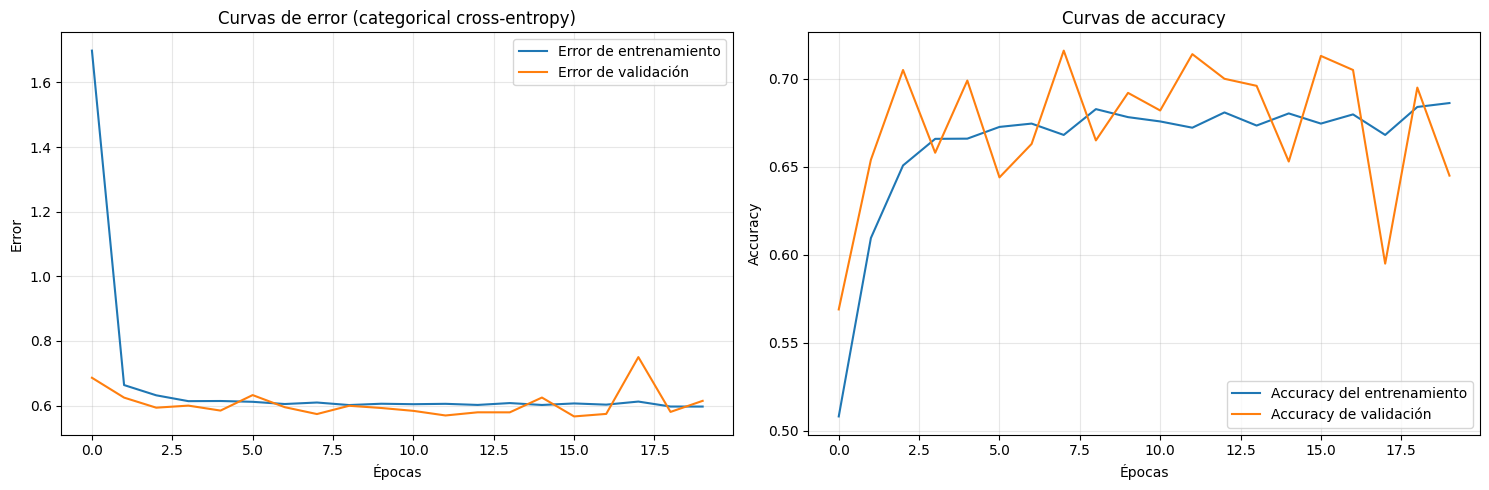

In [610]:
plot_history_graphics(history_cifar2)

In [631]:
model_cifar2.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.2290 - loss: 1.8824


[1.882355809211731, 0.2290000021457672]

#### Descongelando la última capa

In [611]:
model_cifar8.layers[-1].trainable = True

In [612]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 16,512 (64.50 KB)

 Non-trainable params: 400,704 (1.53 MB)

 Optimizer params: 836,498 (3.19 MB)

In [613]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [614]:
model_cifar2_unfreeze1 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [615]:
model_cifar2_unfreeze1.summary()

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 16,770 (65.51 KB)

 Non-trainable params: 400,704 (1.53 MB)

In [616]:
model_cifar2_unfreeze1.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [617]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [618]:
history_cifar2_unfreeze1 = model_cifar2_unfreeze1.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5548 - loss: 0.9993 - val_accuracy: 0.6020 - val_loss: 0.6641
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6611 - loss: 0.6272 - val_accuracy: 0.7040 - val_loss: 0.5884
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6797 - loss: 0.6072 - val_accuracy: 0.7180 - val_loss: 0.5669
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6821 - loss: 0.6050 - val_accuracy: 0.7150 - val_loss: 0.5671
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6844 - loss: 0.6016 - val_accuracy: 0.7260 - val_loss: 0.5637
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6879 - loss: 0.5971 - val_accuracy: 0.7250 - val_loss: 0.5636
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6842 - loss: 0.6035 - val_accuracy: 0.7200 - val_loss: 0.5678
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6978 - loss: 0.5866 - val_accuracy: 0.

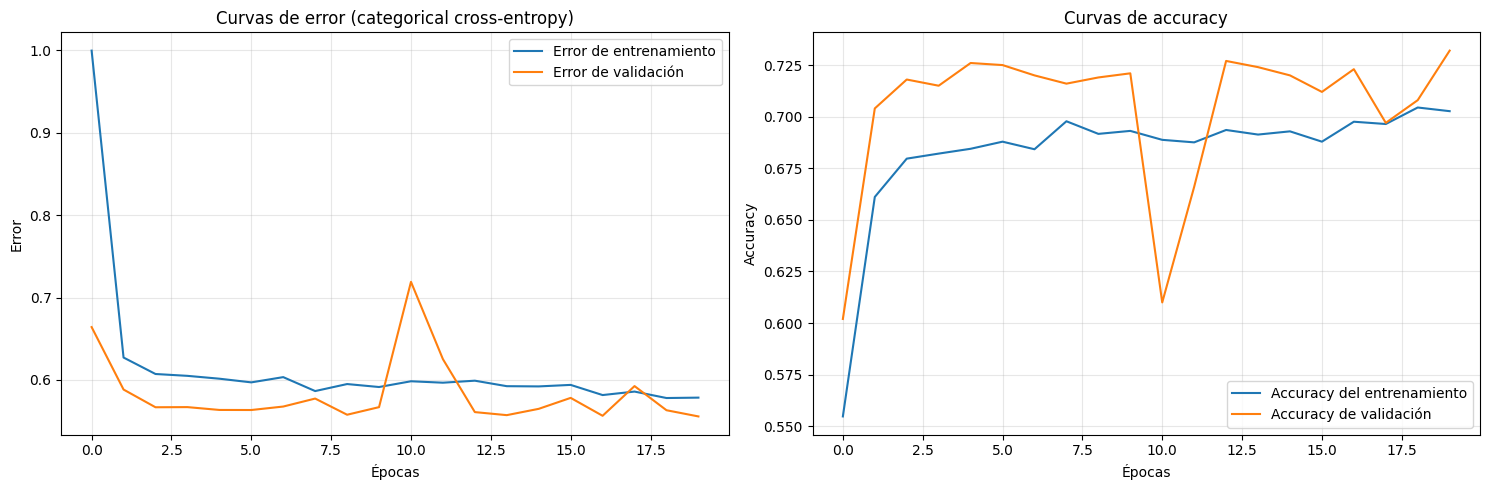

In [619]:
plot_history_graphics(history_cifar2_unfreeze1)

In [620]:
model_cifar2_unfreeze1.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.7045 - loss: 0.5717


[0.5717491507530212, 0.7045000195503235]

#### Descongelando las capas densas

(TODO) Al ver que no se obtuvieron mejores resultados, elegimos descongelar todas las capas densas:

In [621]:
for i in [-1,-2,-3]:
    model_cifar8.layers[i].trainable = True

In [622]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 287,040 (1.09 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [623]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [624]:
model_cifar2_unfreeze_dense = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [625]:
model_cifar2_unfreeze_dense.summary()

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 287,298 (1.10 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [626]:
model_cifar2_unfreeze_dense.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [627]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [628]:
history_cifar2_unfreeze_dense = model_cifar2_unfreeze_dense.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6964 - loss: 0.5818 - val_accuracy: 0.7260 - val_loss: 0.5447
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7700 - loss: 0.4894 - val_accuracy: 0.7300 - val_loss: 0.5444
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.4498 - val_accuracy: 0.7190 - val_loss: 0.5474
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7932 - loss: 0.4436 - val_accuracy: 0.8110 - val_loss: 0.3924
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4275 - val_accuracy: 0.8310 - val_loss: 0.3683
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8170 - loss: 0.3994 - val_accuracy: 0.8310 - val_loss: 0.3657
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8200 - loss: 0.3939 - val_accuracy: 0.8390 - val_loss: 0.3526
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8281 - loss: 0.3830 - val_accuracy: 0.

TODO: Model checkpoint?

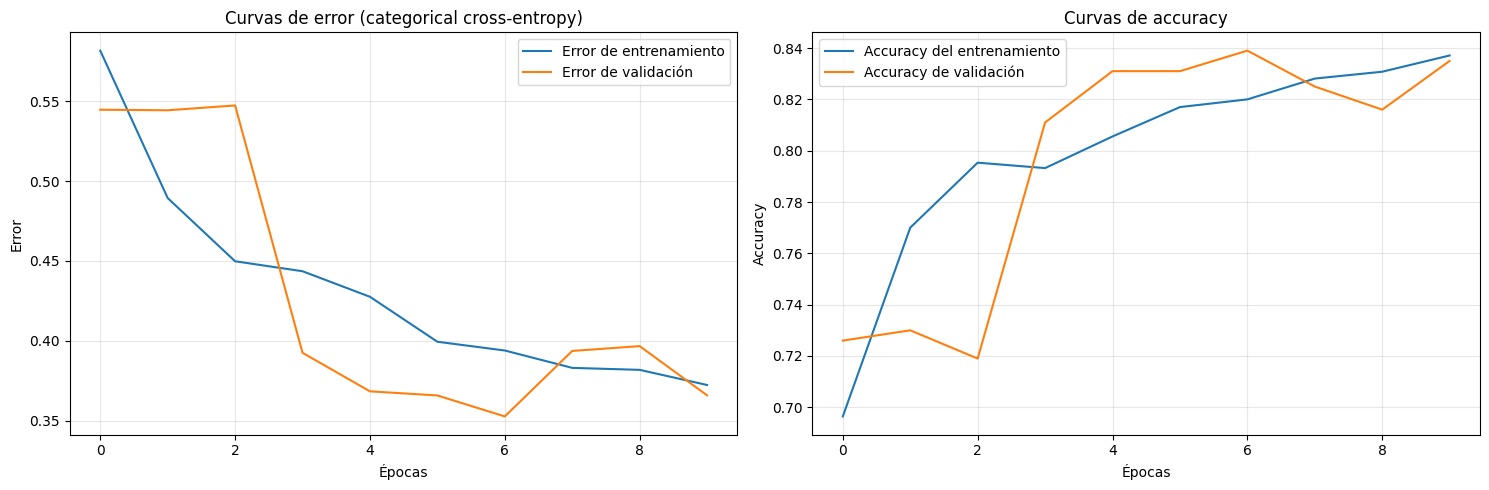

In [629]:
plot_history_graphics(history_cifar2_unfreeze_dense)

In [630]:
model_cifar2_unfreeze_dense.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.8170 - loss: 0.4165


[0.41654080152511597, 0.8169999718666077]

#### Descongelando las últimas capas convolucionales

In [711]:
for i in range(-6,0):
    model_cifar8.layers[i].trainable = True

In [712]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 360,896 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [713]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [714]:
model_cifar2_unfreeze_lastconv = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [715]:
model_cifar2_unfreeze_lastconv.summary()

Model: "sequential_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 361,154 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [716]:
model_cifar2_unfreeze_lastconv.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [717]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [718]:
history_cifar2_unfreeze_lastconv = model_cifar2_unfreeze_lastconv.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7614 - loss: 0.5180 - val_accuracy: 0.8280 - val_loss: 0.4069
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - loss: 0.4337 - val_accuracy: 0.7060 - val_loss: 0.6810
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8077 - loss: 0.4172 - val_accuracy: 0.8430 - val_loss: 0.3706
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8368 - loss: 0.3685 - val_accuracy: 0.8250 - val_loss: 0.4020
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8331 - loss: 0.3679 - val_accuracy: 0.8530 - val_loss: 0.3542
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.3461 - val_accuracy: 0.7440 - val_loss: 0.6184
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8469 - loss: 0.3443 - val_accuracy: 0.8390 - val_loss: 0.4022
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.3288 - val_accuracy: 0.

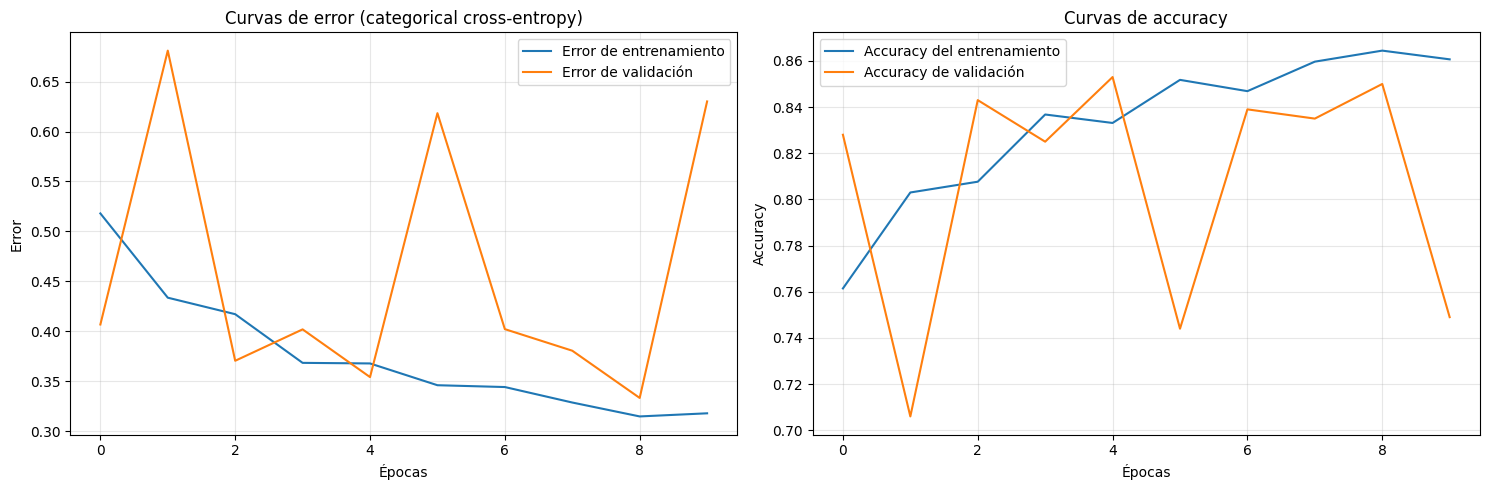

In [719]:
plot_history_graphics(history_cifar2_unfreeze_lastconv)

In [720]:
model_cifar2_unfreeze_lastconv.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.7440 - loss: 0.6127


[0.6126516461372375, 0.7440000176429749]

TODO: Model checkpoint? Probar con cantidades de capas intermedias? Probar con más? Notar que el óptimo acá fue aún mejor respecto al anterior, entonces capaz usando checkpoint va mejor el accuracy respecto a test.
    Métricas?